In [130]:
from langgraph.graph import StateGraph, END
from typing import TypedDict,List
import random

In [131]:
class AgentState(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int

In [132]:
def guess_node(state: AgentState) -> AgentState:
    guessed_number = random.randint(state['lower_bound'] , state['upper_bound'])
    state['guesses'].append(guessed_number)
    state['attempts'] += 1
    return state

In [ ]:
def decide_next(state: AgentState) -> str:
    guessed_number = state['guesses'][-1]
    if guessed_number == 15 or state['attempts'] >= 7:
        return "end"
    return "continue"

In [134]:
def update_bounds_node(state: AgentState) -> AgentState:
    guessed_number = state['guesses'][-1]
    if guessed_number < 15:
        state['lower_bound'] = guessed_number + 1
    else:
        state['upper_bound'] = guessed_number - 1
    return state

In [135]:
graph = StateGraph(AgentState)

graph.add_node("guess", guess_node)
graph.add_node("update", update_bounds_node)
graph.add_node("decide_next", lambda state : state)

graph.set_entry_point("guess")

graph.add_edge("guess","decide_next")
graph.add_edge("update","guess")

graph.add_conditional_edges(
    "decide_next",
    decide_next,
    {
        # Edge : Node
        "end": END,
        "continue": "update"
    }
)

app = graph.compile()

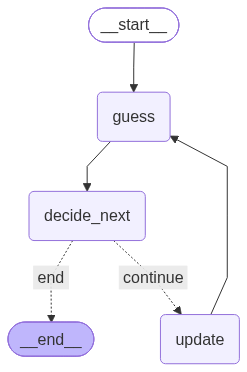

In [136]:
app

In [137]:
app.invoke({
    "player_name": "Bishoy",
    "guesses": [],
    "attempts": 0,
    "lower_bound": 1,
    "upper_bound": 20
})

{'player_name': 'Bishoy',
 'guesses': [18, 13, 15],
 'attempts': 3,
 'lower_bound': 14,
 'upper_bound': 17}